<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif;box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h1 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Aquaverse Short Course Part III: Mapping Satellite Imagery
</h1>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    This notebook illustrates how to apply the pretrained <b>Mixture Density Network (MDN)</b> models within the Aquaverse framework to map spatial distributions of Water Quality (WQ) parameters over entire satellite scenes. You will learn how to load satellite image cubes, preprocess spatial data, execute parallelized MDN model inferences using Dask execution grids, and output high-resolution geographic raster maps of water constituents alongside pixel-by-pixel uncertainty boundaries.
</p>

<h3 style="color: #004080; margin-top: 25px;"><b>Course Objectives</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #d35400;">■</span> <b>01. Downloading Example Satellite Data:</b> Download and extract sample satellite imagery to use as the base demonstration dataset.</li>
    <li><span style="color: #d35400;">■</span> <b>02. Visualizing TOA and R<sub>rs</sub> Data:</b> Load, inspect, and plot Top-of-Atmosphere (TOA) reflectance and surface Remote Sensing Reflectance (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>) data layers.</li>
    <li><span style="color: #d35400;">■</span> <b>03. Generating MDN Predictions:</b> Apply the pretrained MDN models to estimate target water quality parameters across the spatial extent of the imagery.</li>
    <li><span style="color: #d35400;">■</span> <b>04. Visualizing Predictions and Uncertainties:</b> Map the generated spatial predictions alongside their corresponding pixel-by-pixel uncertainty boundaries.</li>
    <li><span style="color: #d35400;">■</span> <b>05. Exporting and Saving Products:</b> Save and export the final prediction and uncertainty arrays into GIS-compatible raster formats for external use.</li>
</ul>

<div style="background-color: #fcf8e3; color: #8a6d3b; padding: 15px; border: 1px solid #faebcc; border-left: 6px solid #8a6d3b; margin: 20px 0; font-weight: 500;box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">
    <strong>Requirement:</strong> Assumes that the user has successfully run the previous notebook in this tutorial (<a href="AQV_2_MDN_predictions.ipynb" style="color: #0056b3; text-decoration: underline; font-weight: bold;">AQV_2_MDN_predictions.ipynb</a>), has a working Dask/Xarray environment, and has verified local access to the required internet resources to download the demo dataset.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="margin-bottom: 20px;">
    <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
    <span style="color: #444;">Science Systems and Applications, Inc. / NASA Goddard Space Flight Center</span><br>
    <span style="color: #666;">August 2026</span>
</div>

<h4 style="color: #004080; margin-bottom: 10px;">Technical Contacts</h4>
<table style="width: 100%; border-collapse: collapse; border: 1px solid #ddd;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Domain</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Section Lead</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Email</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">BPs & IOP Products</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Ryan E. O'Shea</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:ryan.oshea@ssaihq.com" style="color: #0056b3; font-weight: bold;">ryan.oshea@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Uncertainties</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Arun Saranathan</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:arun.saranathan@ssaihq.com" style="color: #0056b3; font-weight: bold;">arun.saranathan@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Atmospheric Correction</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Akash Ashapure</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:akash.ashapure@ssaihq.com" style="color: #0056b3; font-weight: bold;">akash.ashapure@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Stream Website</td>
            <td style="padding: 10px; border: 1px solid #ddd;">William Wainwright</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:william.wainwright@ssaihq.com" style="color: #0056b3; font-weight: bold;">william.wainwright@ssaihq.com</a></td>
        </tr>
    </tbody>
</table>

</div>

In [15]:
# -*- coding: utf-8 -*-# 
# 
# Import the base python packages needed for this notebook
import numpy                                                          as np
import xarray                                                         as xr
import scipy
import re
import os
import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
sys.path.append("C:\\Users\\asaranat\\OneDrive - NASA\\Code\\MDN-STREAM\\")

# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import download_example_imagery, display_sat_rgb, get_sensor_bands, extract_satellite_data, overlay_rgb_mdn_preds_limits
from   MDN                        import extract_satellite_data, get_sensor_bands, translate_wavelengths_to_landsat_bands, map_cube_mdn

ImportError: cannot import name 'overlay_rgb_mdn_preds_limits' from 'MDN' (C:\Users\asaranat\OneDrive - NASA\Code\MDN-STREAM\MDN\__init__.py)

In [2]:
# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0; margin-bottom: 20px; font-size: 1.5em; word-wrap: break-word;">
    Section 1: Downloading Satellite Data to Test MDN Performance
</h2>

<p style="margin-bottom: 15px; word-wrap: break-word;">To properly test and evaluate our <strong>MDN (Mixture Density Network)</strong> package, we need to work with actual, real-world satellite imagery. However, not just any satellite data will do. Please ensure your imagery meets the following specifications:</p>

<ul style="padding-left: 20px; margin-bottom: 20px; list-style-type: disc;">
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Level-2 Processing (Atmospherically Corrected):</strong> The satellite data must be Level-2, meaning it has undergone Atmospheric Correction (AC). This correction can be performed using a variety of standard techniques, such as <code>ACOLITE</code>, <code>L2GEN</code>, <code>POLYMER</code>, or our own native <code>AQUAVERSE-AC</code> processor.
    </li>
    <li style="margin-bottom: 10px; word-wrap: break-word;">
        <strong>Land Masking:</strong> The datasets should be land-masked to isolate the aquatic pixels and optimize processing efficiency.
    </li>
</ul>

<div style="background-color: #f8f9fa; border-left: 4px solid #c0392b; padding: 15px; margin: 20px 0; border-radius: 0 4px 4px 0; box-sizing: border-box;">
    <p style="margin: 0; font-weight: 500; word-wrap: break-word;">
        💡 <strong>Need data to get started?</strong><br>
        To help you jump right into this tutorial, we have provided curated sample satellite datasets. You can automatically fetch and download this data directly within your notebook using our built-in <code>download_example_imagery()</code> function.
    </p>
</div>

<div style="background-color: #fdf2f2; color: #9b1c1c; padding: 15px; border: 1px solid #f8b4b4; border-left: 6px solid #e11d48; margin: 20px 0; box-sizing: border-box; border-radius: 4px;">
    <strong style="font-size: 1.1em;">⚠️ Team Internal Note: Things to implement in this section</strong>
    <ol style="margin-top: 5px; margin-bottom: 0; padding-left: 20px; line-height: 1.7;">
        <li><b>Add demo catalog functionality:</b> Show an interactive list or printout of all demo cubes currently available on our servers for download.</li>
        <li><b>Explain L1 vs. L2 differences:</b> Clearly differentiate between Level-1 (TOA reflectance, <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">&rho;<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">t</sub></span>) and Level-2 (Surface reflectance, <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>). Explicitly point out to the user that the unmasked visual RGB composites use L1 data, whereas the actual MDN processor strictly requires the atmospherically corrected and land-masked L2 data.</li>
    </ol>
</div>

<hr style="border: 0; border-top: 1px solid #eeeeee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 3.1
</div>

</div>

<div style="padding: 20px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; width: auto; max-width: 100%; box-sizing: border-box; overflow: hidden;">

<p style="margin-bottom: 15px; word-wrap: break-word;"> In the first demo will download an image of the San Francisco Bay acquired by the Sentinel-3 OLCI sensor on March 16, 2019.We will download this data using <code>download_example_imagery</code> from the <code>MDN</code> package.</p> 

</div>

In [3]:
# Provide data details for the example imagery to be downloaded
sensor= "OLCI"
products = "chl,tss"
date= "03-16-2019"
location = "San Francisco Bay"
tile_path = download_example_imagery(sensor= sensor, date= date, location= location)

# Let us load the NetCDF lazily and display the global attributes
ds = xr.open_dataset(tile_path)

# A dictionary mapping clear, user-friendly labels to your specific NetCDF keys
# 1. Gather the core metadata dictionary
useful_metadata = {
    "Core Information": {
        "Processor/Software": ds.attrs.get("generated_by"),
        "Processing Date": ds.attrs.get("generated_on"),
        "Sensor Baseline": ds.attrs.get("sensor"),
        "Acquisition Time": ds.attrs.get("isodate"),
        "File Type": ds.attrs.get("acolite_file_type"),
    },
    "Spatial Dimensions & Bounds": {
        "Image Dimensions (Px)": ds.attrs.get("data_dimensions"),
        "Spatial Bounding Box": ds.attrs.get("limit"),
    },
    "Atmospheric & Environmental Context": {
        "Solar Zenith Angle (SZA)": round(ds.attrs.get("sza", 0), 2),
        "View Zenith Angle (VZA)": round(ds.attrs.get("vza", 0), 2),
        "Ozone Column (uoz)": ds.attrs.get("uoz"),
        "Water Vapor (uwv)": ds.attrs.get("uwv"),
        "Ancillary Data Source": ds.attrs.get("ancillary_type")
    },
    "Masking Settings (Crucial for MDN)": {
        "Land/Water Masking Wave": f"{ds.attrs.get('l2w_mask_wave')} nm",
        "Water Mask Threshold": ds.attrs.get("l2w_mask_threshold"),
        "High TOA Cloud Masking": str(ds.attrs.get("l2w_mask_high_toa"))
    }
}

# 2. Extract variable bases and drop repeats/wavelengths
coordinate_vars = {'lat', 'lon', 'transverse_mercator', 'x', 'y'}
unique_parameter_keys = set()

for var in ds.data_vars:
    if var in coordinate_vars:
        continue
    # Strip trailing underscores followed by numbers (e.g., rhow_443 -> rhow)
    base_key = re.sub(r'_\d+$', '', var)
    unique_parameter_keys.add(base_key)

# Convert back to a sorted list
sorted_keys = sorted(list(unique_parameter_keys))

# 3. Print the full summary
print("=" * 60)
print("             SATELLITE NETCDF MULTI-PREVIEW             ")
print("=" * 60)

# Print attributes
for section, items in useful_metadata.items():
    print(f"\n📁 {section.upper()}")
    print("-" * len(section))
    for key, value in items.items():
        if isinstance(value, list) or str(type(value)).endswith("ndarray'>"):
            value = [round(x, 4) for x in value] if isinstance(value[0], (int, float)) else value
        print(f"  🔹 {key:<26} : {value}")

# Print unique parameter fields
print("\n📊 AVAILABLE PARAMETER KEYS (Wavelength Repeats Dropped)")
print("-------------------------------------------------------")
print(f"  👉 {', '.join(sorted_keys)}")
print("\n" + "=" * 60)

             SATELLITE NETCDF MULTI-PREVIEW             

📁 CORE INFORMATION
----------------
  🔹 Processor/Software         : ACOLITE
  🔹 Processing Date            : 2024-08-20 13:18:53 EDT
  🔹 Sensor Baseline            : S3B_OLCI
  🔹 Acquisition Time           : 2019-03-16T18:42:38.875566+00:00
  🔹 File Type                  : L2R

📁 SPATIAL DIMENSIONS & BOUNDS
---------------------------
  🔹 Image Dimensions (Px)      : [589 768]
  🔹 Spatial Bounding Box       : [37.1073, -123.276, 38.3802, -121.5071]

📁 ATMOSPHERIC & ENVIRONMENTAL CONTEXT
-----------------------------------
  🔹 Solar Zenith Angle (SZA)   : 45.1
  🔹 View Zenith Angle (VZA)    : 11.58
  🔹 Ozone Column (uoz)         : 0.3127064710481136
  🔹 Water Vapor (uwv)          : 1.0152477237338193
  🔹 Ancillary Data Source      : GMAO_MERRA2_MET

📁 MASKING SETTINGS (CRUCIAL FOR MDN)
----------------------------------
  🔹 Land/Water Masking Wave    : 1020 nm
  🔹 Water Mask Threshold       : 0.05
  🔹 High TOA Cloud Masking     

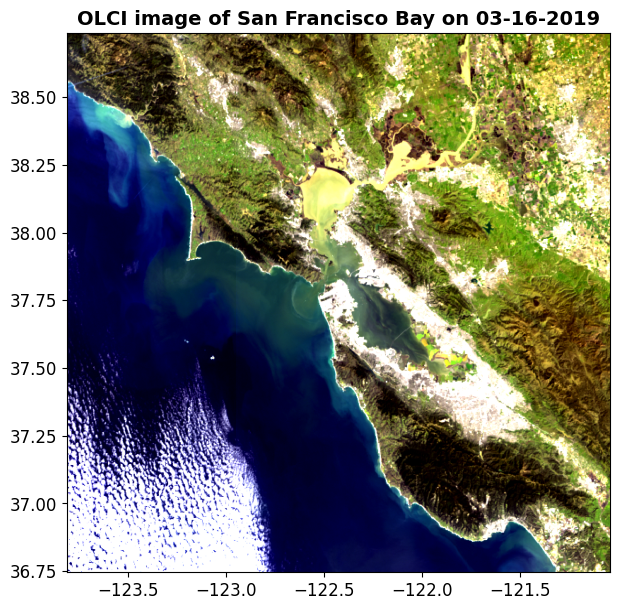

In [4]:
# now display the RGB of the downloaded tile -- this will use the rhos data from the NetCDF file to create a true color image
img_rgb = display_sat_rgb(tile_path, sensor, figsize=(7,7), title=f"{sensor} image of {location} on {date}", ipython_mode=True)

NetCDF file source detected. Delegating to extract_netcdf_satellite_rrs for sensor OLCI: sat_cube.nc
Flat group schema detected. Accessing root level.
Extracted/Assigned Dataset CRS: EPSG:4326
Auto-detected variable type: RRS
Selected variables: ['Rrs_412', 'Rrs_443', 'Rrs_490', 'Rrs_510', 'Rrs_560', 'Rrs_620', 'Rrs_665', 'Rrs_674', 'Rrs_681', 'Rrs_709', 'Rrs_754', 'Rrs_779']
Output spectral shape: (12, 589, 768) (band, y, x)
Latitude/Longitude shape: (589, 768)


Text(0.5, 1.0, 'The Rrs of the bands corresponding to 411 nm')

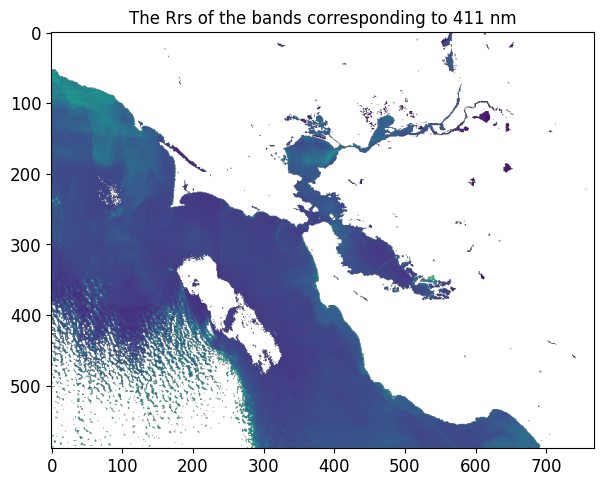

In [5]:
# Let us now extract the Rrs data
bands = get_sensor_bands(sensor)
da= extract_satellite_data(tile_path, sensor=sensor, bands=bands, wavelength_unit="nm", verbose=True, flag_toa=False)

# Display the results - for the first band
fig1, ax1 = plt.subplots(figsize=(7,7))
fig1.patch.set_visible(True)

img1 = ax1.imshow(da.isel(band=0), cmap="viridis")
ax1.set_title(f'The Rrs of the bands corresponding to {bands[0]} nm')

In [6]:
# Generate MDN predictions for this dataset
map_preds, op_slices = map_cube_mdn(da, sensor=sensor, products="chl,tss", return_uncert=True, uncert_mode="limits", scaler_mode="invert", progress_vis=True)
map_preds

Computing MDN predictions across chunks...
[########################################] | 100% Completed | 175.76 s


<xarray.Dataset> Size: 14MB
Dimensions:           (model: 1, output: 2, y: 589, x: 768)
Coordinates:
  * model             (model) int64 8B 0
  * output            (output) int64 16B 0 1
    spatial_ref       int64 8B 0
    latitude          (y, x) float32 2MB 38.74 38.74 38.74 ... 36.75 36.75 36.75
    longitude         (y, x) float32 2MB -123.3 -123.3 -123.3 ... -121.6 -121.6
  * y                 (y) int64 5kB 0 1 2 3 4 5 6 ... 583 584 585 586 587 588
  * x                 (x) int64 6kB 0 1 2 3 4 5 6 ... 762 763 764 765 766 767
Data variables:
    uncertainty_high  (model, y, x, output) float32 4MB -999.0 -999.0 ... -999.0
    uncertainty_low   (model, y, x, output) float32 4MB -999.0 -999.0 ... -999.0
    predictions       (model, y, x, output) float32 4MB -999.0 -999.0 ... -999.0

In [ ]:
# Extract the min and max values directly from your latitude and longitude coordinates
min_lon = float(da.longitude.min())
min_lat = float(da.latitude.min())
max_lon = float(da.longitude.max())
max_lat = float(da.latitude.max())

# Format as a standard bounding box tuple
extent = (min_lon, max_lon, min_lat, max_lat)

str1 = f"MDN Chlorophyll-a predictions"
fig1 = overlay_rgb_mdn_preds_limits(rgb_img= img_rgb, model_preds = map_preds["predictions"].isel(model=0, output=op_slices["chl"]), extent= extent, 
                                    img_uncert_low= map_preds["uncertainty_low"].isel(model=0, output=op_slices["chl"]),
                                    img_uncert_high = map_preds["uncertainty_high"].isel(model=0, output=op_slices["chl"]),
                                    product_name=str1, pred_ticks= [-2, -1, 0, 1, 2], pred_uncert_ticks = [-2, -1, 0, 1, 2], figsize=(16, 7))

NameError: name 'overlay_rgb_mdn_preds_limits' is not defined

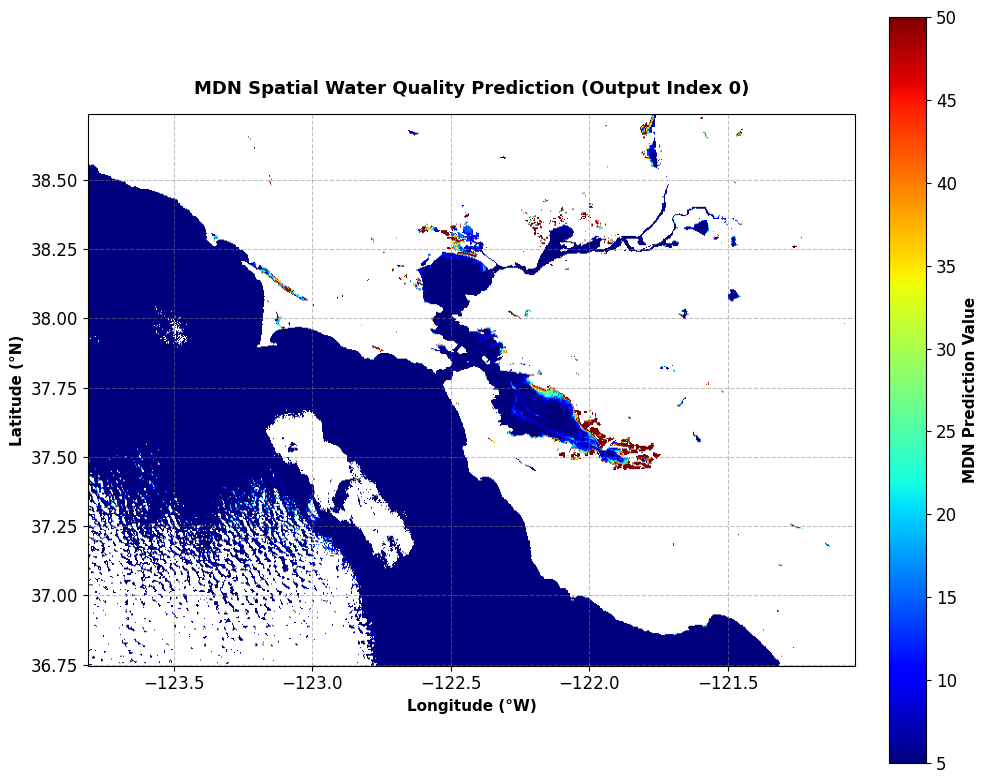

In [11]:
# Extract the min and max values directly from your latitude and longitude coordinates
min_lon = float(da.longitude.min())
min_lat = float(da.latitude.min())
max_lon = float(da.longitude.max())
max_lat = float(da.latitude.max())

# Format as a standard bounding box tuple
extent = (min_lon, max_lon, min_lat, max_lat)

# 2. Slice out the first model and the first output variable
# Shape transitions from (1, 589, 768, 2) to (589, 768)
pred_slice = map_preds["predictions"].isel(model=0, output=op_slices["chl"])

# Mask out background -999.0 values so they are rendered transparently
pred_masked = pred_slice.where(pred_slice != -999.0)

# 3. Create the Matplotlib plot
plt.figure(figsize=(10, 8), dpi=100)

# Display the image using imshow with the calculated GPS extent
im = plt.imshow(
    pred_masked.values, 
    extent=extent, 
    cmap="jet", 
    origin="upper",  # Tells matplotlib the top of the array maps to the north bound (max_lat)
    vmax=50,
    vmin=5.
)

# Add visual indicators and labels
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("MDN Prediction Value", fontsize=11, fontweight="bold")

plt.xlabel("Longitude (°W)", fontsize=11, fontweight="bold")
plt.ylabel("Latitude (°N)", fontsize=11, fontweight="bold")
plt.title("MDN Spatial Water Quality Prediction (Output Index 0)", fontsize=13, fontweight="bold", pad=15)

# Add a coordinates grid
plt.grid(True, linestyle="--", alpha=0.5, color="gray")

plt.tight_layout()
plt.show()



In [10]:
op_slices['chl']

slice(0, 1, None)